# RUN2 t-SNE from the Original Velocity Space

This notebook repeats the RUN2 two-dimensional t-SNE experiment without PCA preprocessing. Each snapshot is represented directly by the concatenated fluctuating velocity components

$$
\mathbf{x}_i = \bigl(u_i(x_1,y_1),\ldots,u_i(x_{n_g},y_{n_g}),v_i(x_1,y_1),\ldots,v_i(x_{n_g},y_{n_g})\bigr) \in \mathbb{R}^{171\,622},
$$

where $n_g=269\times319$ is the number of spatial grid points. The purpose of the experiment is to test whether the phase organization previously observed after PCA preprocessing is already visible in the Euclidean geometry of the original fluctuating velocity fields.

The forced acquisition contains twenty snapshots per actuation period, so the phase label used only for visualization is

$$
\phi_i = i \bmod 20, \qquad \phi_i \in \{0,1,\ldots,19\}.
$$

No PCA, feature mask, downsampling, or standardization is applied by default. The code computes Euclidean distances directly in the original velocity space and then gives this distance matrix to t-SNE. This is equivalent to applying t-SNE to the original vectors with Euclidean metric, but avoids recomputing the high-dimensional distances for every random initialization.


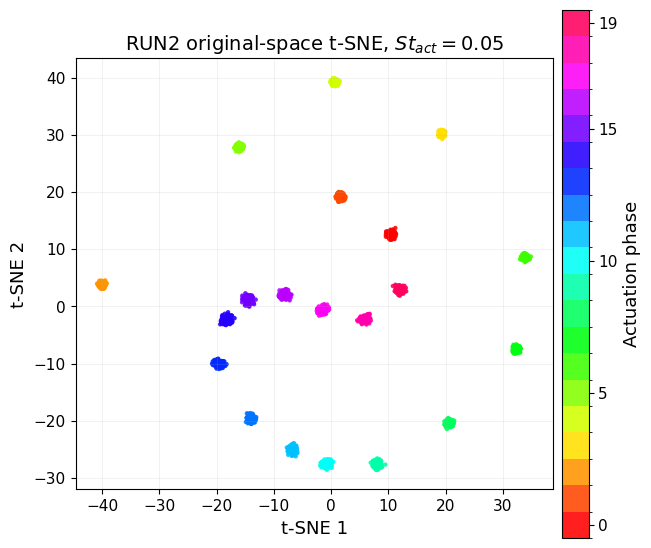

RUN2 original-space t-SNE
  data file: x:\TFG_datos\code\compressed_data\RUN2_PIV_compressed.npz
  distance cache: x:\TFG_datos\code\tsne_data\RUN2_original_space_euclidean_distances_float32.npz
  embedding cache: x:\TFG_datos\code\tsne_data\RUN2_tsne_original_space_2D_perp100_trials1.npz
  loaded from embedding cache: True
  best trial: 1/1
  best KL divergence: 0.1511
  all KL values: [0.1511]
  input ambient dimension: 171622
  snapshots: 2030
  saved PNG: x:\TFG_datos\code\figures\tsne_experiments\run2_tsne_original_space_phase_perp100_trials1.png
  saved PDF: x:\TFG_datos\code\figures\tsne_experiments\run2_tsne_original_space_phase_perp100_trials1.pdf


In [6]:
from pathlib import Path
from time import time
import gc
import json
import warnings

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from sklearn.metrics import pairwise_distances
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore", category=UserWarning)

# -----------------------------------------------------------------------------
# Tunable experiment settings
# -----------------------------------------------------------------------------
RUN_ID = 2
N_PHASES = 20
ST_ACT = 0.05

# t-SNE parameters. The random initialization avoids hidden PCA preprocessing.
PERPLEXITY = 100
N_TRIALS = 1
LEARNING_RATE = 200.0
MAX_ITER = 100000
RANDOM_STATE_START = 0
INIT = "random"
METHOD = "barnes_hut"
ANGLE = 0.5

# Plotting parameters.
POINT_SIZE = 10
POINT_ALPHA = 0.88
FIGSIZE = (6.4, 5.4)
DPI = 300
PHASE_CMAP_NAME = "hsv"

# File locations. The original dataset is read-only; only derived artifacts are saved.
# The candidate search makes the notebook robust to being launched either from
# the repository root (`X:/TFG_datos`) or from the code folder itself.
for candidate in (Path.cwd(), Path.cwd() / "code"):
    candidate_data = candidate / "compressed_data" / f"RUN{RUN_ID}_PIV_compressed.npz"
    if candidate_data.exists():
        CODE_DIR = candidate
        DATA_PATH = candidate_data
        break
else:
    raise FileNotFoundError(
        "Could not locate code/compressed_data/RUN2_PIV_compressed.npz. "
        "Run this notebook from the repository root or from the code folder."
    )

TSNE_DIR = CODE_DIR / "tsne_data"
FIGURE_DIR = CODE_DIR / "figures" / "tsne_experiments"
TSNE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DISTANCE_CACHE = TSNE_DIR / f"RUN{RUN_ID}_original_space_euclidean_distances_float32.npz"
EMBEDDING_CACHE = TSNE_DIR / (
    f"RUN{RUN_ID}_tsne_original_space_2D_perp{PERPLEXITY}_trials{N_TRIALS}.npz"
)
METADATA_PATH = TSNE_DIR / (
    f"RUN{RUN_ID}_tsne_original_space_2D_perp{PERPLEXITY}_trials{N_TRIALS}.json"
)
OUTPUT_STEM = f"run{RUN_ID}_tsne_original_space_phase_perp{PERPLEXITY}_trials{N_TRIALS}"


def phase_labels_for_run(n_snapshots: int, n_phases: int = 20) -> np.ndarray:
    """Assign phase labels from snapshot order for a forced run."""
    return np.arange(n_snapshots, dtype=np.int16) % n_phases


def make_phase_cmap(n_phases: int = 20, cmap_name: str = "hsv"):
    """Return a discrete cyclic colormap for the actuation phases."""
    colors = plt.get_cmap(cmap_name)(np.linspace(0.0, 1.0, n_phases, endpoint=False))
    cmap = ListedColormap(colors, name=f"phase_{n_phases}")
    norm = BoundaryNorm(np.arange(-0.5, n_phases + 0.5, 1.0), cmap.N)
    return cmap, norm


def load_original_snapshot_matrix(data_path: Path) -> tuple[np.ndarray, dict]:
    """Load RUN2 fluctuating velocities and concatenate them into full snapshot vectors.

    The compressed file stores `u` and `v` separately with shape `(N, 269, 319)`.
    This function constructs the matrix `X_original` with shape `(N, 171622)`:
    first all horizontal fluctuation coordinates, then all vertical fluctuation coordinates.
    The output is cast to `float32` to reduce memory use; no PCA, masking, spatial
    downsampling or standardization is performed.
    """
    if not data_path.exists():
        raise FileNotFoundError(f"Missing compressed data file: {data_path}")

    with np.load(data_path) as data:
        # Load the two velocity components one at a time to keep peak memory lower.
        u = data["u"]
        n_snapshots, n_y, n_x = u.shape
        n_grid = n_y * n_x

        # Allocate the final original-space snapshot matrix once.
        X_original = np.empty((n_snapshots, 2 * n_grid), dtype=np.float32)
        X_original[:, :n_grid] = u.reshape(n_snapshots, n_grid)
        del u
        gc.collect()

        v = data["v"]
        X_original[:, n_grid:] = v.reshape(n_snapshots, n_grid)
        del v
        gc.collect()

    metadata = {
        "n_snapshots": int(n_snapshots),
        "grid_shape": (int(n_y), int(n_x)),
        "n_grid_points": int(n_grid),
        "ambient_dimension": int(2 * n_grid),
        "dtype": str(X_original.dtype),
    }
    return X_original, metadata


def compute_or_load_original_distances() -> tuple[np.ndarray, dict]:
    """Compute or load Euclidean distances between original RUN2 snapshots."""
    if DISTANCE_CACHE.exists():
        with np.load(DISTANCE_CACHE) as data:
            distances = data["distances"].astype(np.float32, copy=False)
            metadata = json.loads(str(data["metadata"].item()))
        metadata["loaded_from_distance_cache"] = True
        return distances, metadata

    t0 = time()
    X_original, metadata = load_original_snapshot_matrix(DATA_PATH)

    # t-SNE uses pairwise affinities, so the Euclidean distance matrix contains
    # the complete original-space information needed by the algorithm.
    distances = pairwise_distances(
        X_original,
        metric="euclidean",
        n_jobs=-1,
    ).astype(np.float32, copy=False)

    # Numerical roundoff can produce tiny nonzero diagonal values; force exact zeros.
    np.fill_diagonal(distances, 0.0)

    metadata.update({
        "distance_metric": "euclidean",
        "distance_time_sec": float(time() - t0),
        "loaded_from_distance_cache": False,
    })

    np.savez_compressed(
        DISTANCE_CACHE,
        distances=distances,
        metadata=json.dumps(metadata),
    )

    del X_original
    gc.collect()
    return distances, metadata


def compute_or_load_tsne_embedding() -> tuple[dict, dict]:
    """Compute or load the PCA-free t-SNE embedding from original-space distances."""
    if EMBEDDING_CACHE.exists():
        with np.load(EMBEDDING_CACHE) as data:
            result = {
                "embedding": data["embedding"].astype(np.float32),
                "phase_labels": data["phase_labels"].astype(np.int16),
                "best_kl": float(data["best_kl"]),
                "best_trial": int(data["best_trial"]),
                "all_kls": data["all_kls"].astype(float),
                "loaded_from_embedding_cache": True,
            }
            metadata = json.loads(str(data["metadata"].item()))
        return result, metadata

    distances, metadata = compute_or_load_original_distances()
    n_snapshots = distances.shape[0]
    phase_labels = phase_labels_for_run(n_snapshots, N_PHASES)

    embeddings = []
    kl_values = []
    t0 = time()

    for trial in range(N_TRIALS):
        random_state = RANDOM_STATE_START + trial
        print(f"Running original-space t-SNE trial {trial + 1}/{N_TRIALS} "
              f"with random_state={random_state}...")

        model = TSNE(
            n_components=2,
            perplexity=PERPLEXITY,
            learning_rate=LEARNING_RATE,
            max_iter=MAX_ITER,
            init=INIT,
            metric="precomputed",
            method=METHOD,
            angle=ANGLE,
            random_state=random_state,
            verbose=1,
        )
        embedding = model.fit_transform(distances).astype(np.float32)
        embeddings.append(embedding)
        kl_values.append(float(model.kl_divergence_))
        print(f"  KL divergence: {model.kl_divergence_:.4f}")

    all_kls = np.asarray(kl_values, dtype=float)
    best_trial = int(np.argmin(all_kls))
    best_embedding = embeddings[best_trial]

    metadata.update({
        "run_id": RUN_ID,
        "st_act": ST_ACT,
        "n_phases": N_PHASES,
        "perplexity": PERPLEXITY,
        "n_trials": N_TRIALS,
        "learning_rate": LEARNING_RATE,
        "max_iter": MAX_ITER,
        "init": INIT,
        "method": METHOD,
        "angle": ANGLE,
        "random_state_start": RANDOM_STATE_START,
        "tsne_time_sec": float(time() - t0),
        "best_trial": best_trial,
        "best_kl": float(all_kls[best_trial]),
        "all_kls": all_kls.tolist(),
        "loaded_from_embedding_cache": False,
    })

    np.savez_compressed(
        EMBEDDING_CACHE,
        embedding=best_embedding,
        phase_labels=phase_labels,
        best_kl=float(all_kls[best_trial]),
        best_trial=best_trial,
        all_kls=all_kls,
        metadata=json.dumps(metadata),
    )
    METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    result = {
        "embedding": best_embedding,
        "phase_labels": phase_labels,
        "best_kl": float(all_kls[best_trial]),
        "best_trial": best_trial,
        "all_kls": all_kls,
        "loaded_from_embedding_cache": False,
    }
    return result, metadata


def plot_tsne_embedding_by_phase(result: dict):
    """Plot the two-dimensional embedding with one color for each phase label."""
    embedding = result["embedding"]
    phases = result["phase_labels"]
    phase_cmap, phase_norm = make_phase_cmap(N_PHASES, PHASE_CMAP_NAME)

    fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)
    scatter = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=phases,
        cmap=phase_cmap,
        norm=phase_norm,
        s=POINT_SIZE,
        alpha=POINT_ALPHA,
        linewidths=0,
        rasterized=True,
    )

    ax.set_xlabel("t-SNE 1", fontsize=13)
    ax.set_ylabel("t-SNE 2", fontsize=13)
    ax.set_title(
        rf"RUN{RUN_ID} original-space t-SNE, $St_{{act}}={ST_ACT:.2f}$",
        fontsize=14,
    )
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.20, linewidth=0.6)
    ax.tick_params(labelsize=11)

    cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
    cbar.set_label("Actuation phase", fontsize=13)
    cbar.set_ticks([0, 5, 10, 15, 19])
    cbar.ax.tick_params(labelsize=11)

    png_path = FIGURE_DIR / f"{OUTPUT_STEM}.png"
    pdf_path = FIGURE_DIR / f"{OUTPUT_STEM}.pdf"
    fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    return png_path, pdf_path


result, metadata = compute_or_load_tsne_embedding()
png_path, pdf_path = plot_tsne_embedding_by_phase(result)

print("RUN2 original-space t-SNE")
print(f"  data file: {DATA_PATH}")
print(f"  distance cache: {DISTANCE_CACHE}")
print(f"  embedding cache: {EMBEDDING_CACHE}")
print(f"  loaded from embedding cache: {result['loaded_from_embedding_cache']}")
print(f"  best trial: {result['best_trial'] + 1}/{N_TRIALS}")
print(f"  best KL divergence: {result['best_kl']:.4f}")
print(f"  all KL values: {np.array2string(result['all_kls'], precision=4)}")
print(f"  input ambient dimension: {metadata.get('ambient_dimension')}")
print(f"  snapshots: {metadata.get('n_snapshots')}")
print(f"  saved PNG: {png_path}")
print(f"  saved PDF: {pdf_path}")
